# TopTagging directed $k$NN — graph construction study

Directed $k$NN in $(p_x,p_y,p_z)$ among real (unpadded) constituents.

For each jet with $N$ real particles, the complete directed graph has $N(N-1)$ possible edges.
A $k$NN construction yields up to $N\cdot\min(k,N-1)$ directed edges.

We compare **top** vs **QCD (quark/gluon)** jets: edge count and fraction of possible edges vs $k$.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO = Path("..").resolve()
sys.path[:0] = [str(REPO), str(REPO / "src")]

from cpen.utils.graphs import build_knn_graph, particle_pt_from_four_vectors
from cpen.utils.graph_star import eta_phi_from_four_vectors_torch
from cpen.utils.toptagging import RawTopTaggingSplit, preprocess_particle_features

import scienceplots  # noqa: F401

plt.style.use(["science", "no-latex"])
mpl.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.labelsize": 10,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)

DATA_ROOT = Path("/scratch/gpfs/BHANIN/jdezoort/datasets/toptagging")
FIG_DIR = Path("figures/knn_graph_study")
FIG_DIR.mkdir(parents=True, exist_ok=True)

NUM_PARTICLES = 128
N_JETS = 4000  # balanced subsample target (see load cell)
SEED = 42
K_LIST = [1, 2, 4, 8, 16, 32, 64]
PLOT_K = 8  # representative jet overlays

LABEL_NAMES = {0: "QCD", 1: "top"}
COLORS = {"QCD": "#1f77b4", "top": "#d62728"}

In [2]:
ds = RawTopTaggingSplit(
    data_root=str(DATA_ROOT), split="train", num_particles=NUM_PARTICLES
)
rng = np.random.default_rng(SEED)

# Stratified subsample: equal top / QCD
n_per_class = N_JETS // 2
labels_all = ds.jet_data[:, 0].astype(np.int64)
idx_qcd = np.where(labels_all == 0)[0]
idx_top = np.where(labels_all == 1)[0]
pick_qcd = rng.choice(idx_qcd, size=n_per_class, replace=False)
pick_top = rng.choice(idx_top, size=n_per_class, replace=False)
idx = np.concatenate([pick_qcd, pick_top])
rng.shuffle(idx)

x = torch.stack([ds[int(i)][0].float() for i in idx])
y = torch.tensor(labels_all[idx], dtype=torch.long)
x_raw, _, mask = preprocess_particle_features(x)
pt = particle_pt_from_four_vectors(x_raw)
n_real = mask.float().sum(-1)

print(
    f"n_jets={len(idx)}  "
    f"QCD={(y == 0).sum().item()}  top={(y == 1).sum().item()}  "
    f"mean N: QCD={n_real[y == 0].mean():.1f}  top={n_real[y == 1].mean():.1f}"
)

[data] Loaded 1211000 jets from train.h5 (128 particles/jet, 4 raw features)
n_jets=4000  QCD=2000  top=2000  mean N: QCD=43.9  top=55.1


## Edge count and fraction vs $k$

Fraction of possible edges $= n_\mathrm{edges} \,/\, N(N-1)$ for each jet
(directed complete graph among real particles).

In [3]:
def count_active_edges(incidence: torch.Tensor) -> torch.Tensor:
    """(B,) active directed edges per jet."""
    return incidence.bool().any(dim=-1).float().sum(-1)


def possible_directed_edges(n: torch.Tensor) -> torch.Tensor:
    """N(N-1) for each jet."""
    return n * (n - 1.0)


n_possible = possible_directed_edges(n_real)
rows = []
per_jet = []

for k in K_LIST:
    _ei, _ex, inc = build_knn_graph(x_raw, k=k, mask=mask)
    n_edges = count_active_edges(inc)
    frac = n_edges / n_possible.clamp_min(1.0)
    for cls, name in LABEL_NAMES.items():
        m = y == cls
        rows.append(
            dict(
                k=k,
                label=name,
                n_edges_mean=float(n_edges[m].mean()),
                n_edges_std=float(n_edges[m].std()),
                frac_mean=float(frac[m].mean()),
                frac_std=float(frac[m].std()),
                n_real_mean=float(n_real[m].mean()),
            )
        )
        for i in torch.where(m)[0].tolist():
            per_jet.append(
                dict(
                    k=k,
                    label=name,
                    n_edges=float(n_edges[i]),
                    frac=float(frac[i]),
                    n_real=float(n_real[i]),
                )
            )

stats = pd.DataFrame(rows)
jet_stats = pd.DataFrame(per_jet)
display(stats.pivot(index="k", columns="label", values=["n_edges_mean", "frac_mean"]))

n_edges_mean              frac_mean          
label          QCD          top       QCD       top
k                                                  
1        43.919998    55.123001  0.029086  0.019728
2        87.839996   110.246002  0.058171  0.039456
4       175.679993   220.492004  0.116343  0.078912
8       351.354004   440.984009  0.232485  0.157823
16      701.669495   881.968018  0.456045  0.315646
32     1355.916016  1762.208496  0.783140  0.629008
64     2123.677002  3032.631104  1.007383  0.989535

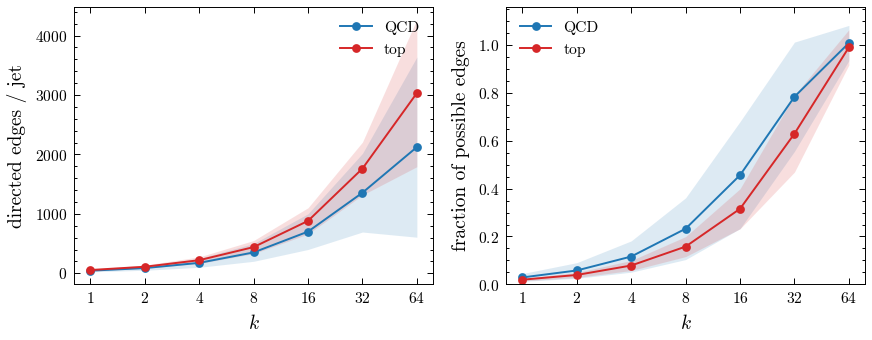

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.6))

for name in ("QCD", "top"):
    sub = stats.loc[stats["label"].eq(name)].sort_values("k")
    axes[0].plot(
        sub["k"],
        sub["n_edges_mean"],
        "o-",
        color=COLORS[name],
        ms=3.5,
        label=name,
    )
    axes[0].fill_between(
        sub["k"],
        sub["n_edges_mean"] - sub["n_edges_std"],
        sub["n_edges_mean"] + sub["n_edges_std"],
        color=COLORS[name],
        alpha=0.15,
        linewidth=0,
    )
    axes[1].plot(
        sub["k"],
        sub["frac_mean"],
        "o-",
        color=COLORS[name],
        ms=3.5,
        label=name,
    )
    axes[1].fill_between(
        sub["k"],
        sub["frac_mean"] - sub["frac_std"],
        sub["frac_mean"] + sub["frac_std"],
        color=COLORS[name],
        alpha=0.15,
        linewidth=0,
    )

axes[0].set_xlabel(r"$k$")
axes[0].set_ylabel(r"directed edges / jet")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(K_LIST)
axes[0].get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
axes[0].legend(frameon=False)

axes[1].set_xlabel(r"$k$")
axes[1].set_ylabel(r"fraction of possible edges")
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(K_LIST)
axes[1].get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
axes[1].set_ylim(0.0, max(0.35, float(stats["frac_mean"].max()) * 1.15))
axes[1].legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "edges_and_fraction_vs_k.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "edges_and_fraction_vs_k.png", bbox_inches="tight")
plt.show()

## Distributions at fixed $k$

Per-jet edge count and fraction for the default training choice $k=8$ (and a denser $k=16$).

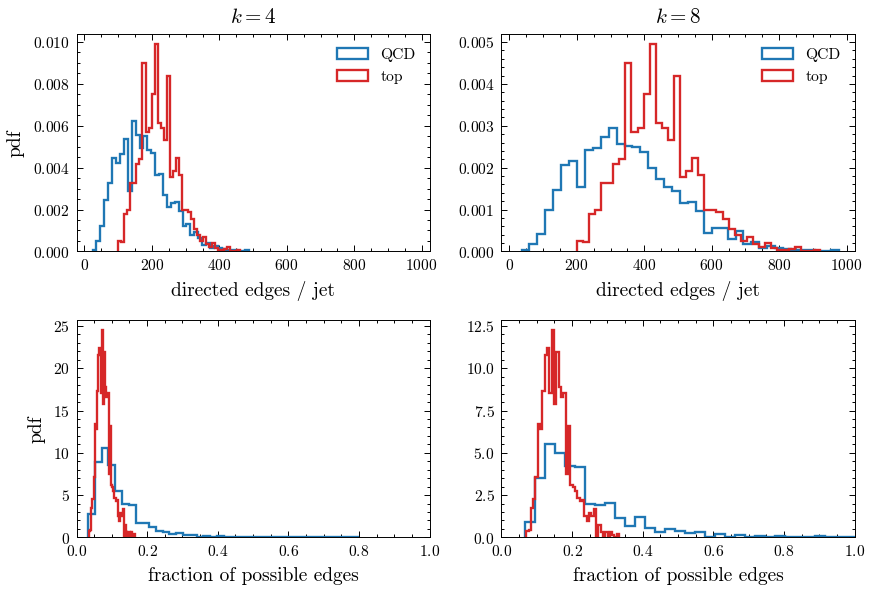

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(6.4, 4.4), sharex="row")

for col, k in enumerate((4, 8)):
    sub = jet_stats.loc[jet_stats["k"].eq(k)]
    for name in ("QCD", "top"):
        s = sub.loc[sub["label"].eq(name)]
        axes[0, col].hist(
            s["n_edges"],
            bins=40,
            density=True,
            histtype="step",
            color=COLORS[name],
            label=name,
            lw=1.2,
        )
        axes[1, col].hist(
            s["frac"],
            bins=40,
            density=True,
            histtype="step",
            color=COLORS[name],
            label=name,
            lw=1.2,
        )
    axes[0, col].set_title(rf"$k={k}$")
    axes[0, col].set_ylabel(r"pdf" if col == 0 else "")
    axes[1, col].set_xlabel(r"fraction of possible edges")
    axes[1, col].set_ylabel(r"pdf" if col == 0 else "")
    axes[0, col].set_xlabel(r"directed edges / jet")
    axes[0, col].legend(frameon=False)
    axes[1, col].set_xlim([0,1])

fig.tight_layout()
fig.savefig(FIG_DIR / "edge_distributions_k8_k16.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "edge_distributions_k8_k16.png", bbox_inches="tight")
plt.show()

## Representative jets in $(\eta,\phi)$

Markers sized by $p_T$; directed $k$NN edges for $k=8$.

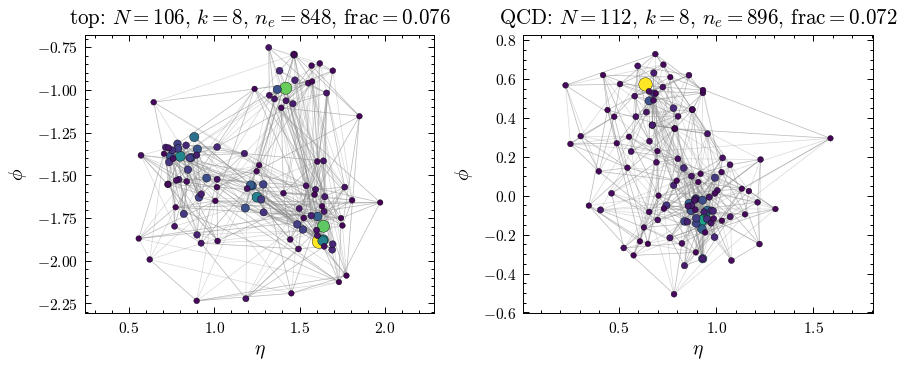

In [6]:
def plot_jet_eta_phi(
    ax,
    x_raw_1: torch.Tensor,
    mask_1: torch.Tensor,
    *,
    k: int = PLOT_K,
    title: str = "",
):
    xr = x_raw_1.unsqueeze(0)
    m = mask_1.unsqueeze(0)
    ei, _, inc = build_knn_graph(xr, k=k, mask=m)
    eta, phi = eta_phi_from_four_vectors_torch(xr)
    eta = eta[0].numpy()
    phi = phi[0].numpy()
    m_np = mask_1.numpy().astype(bool)
    pt_np = particle_pt_from_four_vectors(xr)[0].numpy()

    active = inc[0].bool().any(-1).numpy()
    src = ei[0, :, 0].numpy()
    dst = ei[0, :, 1].numpy()
    for s, d, a in zip(src, dst, active):
        if not a:
            continue
        ax.plot(
            [eta[s], eta[d]],
            [phi[s], phi[d]],
            color="0.55",
            lw=0.35,
            alpha=0.35,
            zorder=1,
        )

    sizes = 8.0 + 40.0 * (pt_np[m_np] / max(pt_np[m_np].max(), 1e-6))
    ax.scatter(
        eta[m_np],
        phi[m_np],
        s=sizes,
        c=pt_np[m_np],
        cmap="viridis",
        vmin=0,
        edgecolors="k",
        linewidths=0.2,
        zorder=2,
    )
    ax.set_xlabel(r"$\eta$")
    ax.set_ylabel(r"$\phi$")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="datalim")


# Pick high-multiplicity examples of each class
fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.8))
for ax, cls, name in zip(axes, (1, 0), ("top", "QCD")):
    cand = torch.where(y == cls)[0]
    order = torch.argsort(n_real[cand], descending=True)
    j = int(cand[order[3]].item())  # skip the absolute fullest outliers a bit
    n_e = count_active_edges(
        build_knn_graph(x_raw[j : j + 1], k=PLOT_K, mask=mask[j : j + 1])[2]
    ).item()
    frac = n_e / max(float(n_real[j] * (n_real[j] - 1)), 1.0)
    plot_jet_eta_phi(
        ax,
        x_raw[j],
        mask[j],
        k=PLOT_K,
        title=rf"{name}: $N={int(n_real[j])}$, $k={PLOT_K}$, "
        rf"$n_e={int(n_e)}$, frac$={frac:.3f}$",
    )

fig.tight_layout()
fig.savefig(FIG_DIR / f"eta_phi_examples_k{PLOT_K}.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / f"eta_phi_examples_k{PLOT_K}.png", bbox_inches="tight")
plt.show()

## Multiplicity context

Because $n_\mathrm{edges}\approx N\cdot\min(k,N-1)$, differences between top and QCD largely track multiplicity when $k\ll N$.

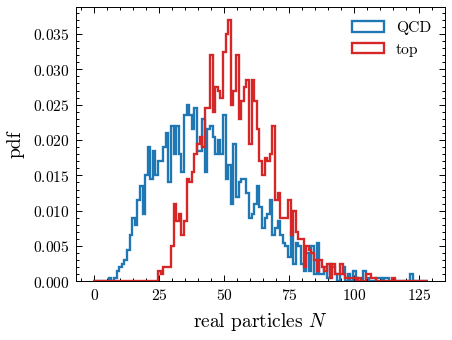

Saved figures under /home/jdezoort/coupled-particle-edge-networks/notebooks/figures/knn_graph_study


In [7]:
fig, ax = plt.subplots(figsize=(3.4, 2.6))
for name, cls in (("QCD", 0), ("top", 1)):
    ax.hist(
        n_real[y == cls].numpy(),
        bins=np.arange(0, NUM_PARTICLES + 2) - 0.5,
        density=True,
        histtype="step",
        color=COLORS[name],
        label=name,
        lw=1.2,
    )
ax.set_xlabel(r"real particles $N$")
ax.set_ylabel(r"pdf")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "multiplicity.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "multiplicity.png", bbox_inches="tight")
plt.show()

print("Saved figures under", FIG_DIR.resolve())